# 🎵 Warner Music GroupBy — Spotify Hit Formula
### SQL + Python Mini-Project | Ironhack Data Analytics Bootcamp
**Team:** Claire & Diana &nbsp;|&nbsp; **Date:** May 2026 &nbsp;|&nbsp; **Dataset:** Kaggle Top 50 Spotify 2019

---

## 🏢 Business Context

**Warner Music GroupBy (WMG)** commits A&R resources to new artists before those artists chart.  
The question is: _can audio features of already-charting songs reveal a pattern that helps WMG filter future investment decisions?_

---

## 🎯 Hypotheses

| | Hypothesis | Status |
|--|--|--|
| **H1** | Top 50 songs share a **universal** audio profile formula usable as a WMR investment filter | ✅ Partially Confirmed |
| **H2** | The hit formula **differs by genre**, requiring genre-specific investment criteria | ✅ Confirmed |

---

## 📋 Notebook Structure

| Section | Focus |
|--|--|
| **1. Setup & Data Loading** | Imports, raw data preview |
| **2. Data Quality & Cleaning** | Column renaming, type casting, null/duplicate checks |
| **3. Formula Analysis** | Universal hit formula baseline (H1) |
| **4. Genre Analysis** | genre audio profiles differentiation (H2) |
| **5. Conclusions & Obstacles** | WMG view on filtering mechanism for A&R teams.
 |


---
## 1. Setup & Data Loading

In [76]:
#Importing libraries

import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

sp_df=pd.read_csv('spotifytop50.csv')


# Code for making the first row as header. Remove if not needed.
#sp_df.columns = sp_df.iloc[0]
sp_df = sp_df.drop(columns=sp_df.columns[0])
sp_df.head()

print("✅ Libraries loaded")

✅ Libraries loaded


In [77]:
# ── Load raw CSV ─────────────────────────────────────────────────────────────
CSV_PATH = "spotifytop50.csv"

sp_df = pd.read_csv(CSV_PATH)
# Drop auto-generated index column if present
sp_df = sp_df.drop(columns=[c for c in sp_df.columns if "Unnamed" in str(c)])

print(f"Shape: {sp_df.shape}  ({sp_df.shape[0]} songs × {sp_df.shape[1]} features)")
sp_df.head(3)

Shape: (50, 13)  (50 songs × 13 features)


,Track.Name,Artist.Name,Genre,Beats.Per.Minute,Energy,Danceability,Loudness..dB..,Liveness,Valence.,Length.,Acousticness..,Speechiness.,Popularity
0,It's You,Ali Gatie,canadian hip hop,96,46,73,-7,19,40,213,37,3,89
1,China,Anuel AA,reggaeton flow,105,81,79,-4,8,61,302,8,9,92
2,boyfriend (with Social House),Ariana Grande,dance pop,190,80,40,-4,16,70,186,12,46,85


---
## 2. Data Quality & Cleaning

### 2.1 Data Quality Audit

Before cleaning, we identify potential issues: messy column names, wrong data types, missing values, and duplicates.

In [78]:
# ── Column names (raw) 
sp_df.columns #get list to clean

Index(['Track.Name', 'Artist.Name', 'Genre', 'Beats.Per.Minute', 'Energy',
       'Danceability', 'Loudness..dB..', 'Liveness', 'Valence.', 'Length.',
       'Acousticness..', 'Speechiness.', 'Popularity'],
      dtype='object')

In [79]:
#Null counts & dtypes check
quality_report= pd.DataFrame({
    'dtype': sp_df.dtypes,
    'null_count': sp_df.isnull().sum(),
    'unique_vals': sp_df.nunique()})
print(quality_report)


                   dtype  null_count  unique_vals
Track.Name        object           0           50
Artist.Name       object           0           38
Genre             object           0           21
Beats.Per.Minute   int64           0           31
Energy             int64           0           31
Danceability       int64           0           29
Loudness..dB..     int64           0            9
Liveness           int64           0           22
Valence.           int64           0           39
Length.            int64           0           44
Acousticness..     int64           0           35
Speechiness.       int64           0           24
Popularity         int64           0           18


In [80]:
#Duplicate rows 
n_dupes = sp_df.duplicated().sum()
print(f"Duplicate rows detected: {n_dupes}")

#Duplicate track names 
col_track = ['Track.Name']
dupe_tracks = sp_df[col_track].duplicated(keep=False)
print(f"Songs with duplicate track names: {dupe_tracks.sum()}")


Duplicate rows detected: 0
Songs with duplicate track names: 0


### 2.2 Cleaning Strategy

| Issue | Strategy | Justification |
|--|--|--|
| Messy column names (dots, caps, trailing punctuation) | Standardise| Consistency for easy handling across Python|
| Numeric features stored as `object` | Cast via `pd.to_numeric` | Enables arithmetic and plotting |
| No missing values detected | No imputation needed | Data is complete |
| Duplicate track names (different versions) | Keep all rows | Each row is a distinct chart entry |

In [81]:
def clean_col_names(df):
    df2 = df.copy()
    df2.columns = df2.columns.map(lambda x: x.lower().replace('.','_'))
    df2 = df2.rename(columns={"loudness__db__": "loudness_db", "length_": "length","acousticness__": "acousticness", 'speechiness_':"speechiness","valence_":"valence"})
    return df2

def convert_numeric(df):
    df2 = df.copy()
    numeric_data = ['beats_per_minute', 'energy','danceability', 'loudness_db', 'liveness', 'valence', 'length','acousticness', 'speechiness', 'popularity']
    for i in numeric_data:
        df2[i] = pd.to_numeric(df2[i])
    return df2

sp_df = clean_col_names(sp_df)
sp_df = convert_numeric(sp_df)
print("✅ Cleaning complete")
print(f"Shape after cleaning: {sp_df.shape}")
sp_df.head(3)

✅ Cleaning complete
Shape after cleaning: (50, 13)


,track_name,artist_name,genre,beats_per_minute,energy,danceability,loudness_db,liveness,valence,length,acousticness,speechiness,popularity
0,It's You,Ali Gatie,canadian hip hop,96,46,73,-7,19,40,213,37,3,89
1,China,Anuel AA,reggaeton flow,105,81,79,-4,8,61,302,8,9,92
2,boyfriend (with Social House),Ariana Grande,dance pop,190,80,40,-4,16,70,186,12,46,85


In [82]:
# ── Post-cleaning check ────────────────────────────────────────────────────────
print("Dtypes after cleaning:")
print(sp_df.dtypes)
print(f"\nNull values remaining: {sp_df.isnull().sum().sum()}")

Dtypes after cleaning:
track_name          object
artist_name         object
genre               object
beats_per_minute     int64
energy               int64
danceability         int64
loudness_db          int64
liveness             int64
valence              int64
length               int64
acousticness         int64
speechiness          int64
popularity           int64
dtype: object

Null values remaining: 0


---
## 3. Formula Analysis — H1: Universal Hit Formula Baseline

**H1 Question:** Do all Top 50 songs converge on a consistent audio profile?

We compute mean ± std for each audio feature. A **low std relative to mean** signals a strong, consistent signal — a candidate for the WMR filter.


In [83]:
#get standard deviations
numeric_data = ['beats_per_minute', 'energy','danceability', 'loudness_db', 'liveness', 'valence', 'length','acousticness', 'speechiness', 'popularity']
mean =[sp_df[i].astype(int).mean(axis=0) for i in numeric_data]
std = [sp_df[i].astype(int).std(axis=0) for i in numeric_data]
std_table = round(sp_df[numeric_data].describe().T[["mean", "std", "min", "max"]],2)


# Add coefficient of variation (std/mean) — lower = more consistent signal
# std_table["CV (%)"] = (desc["std"] / desc["mean"].abs() * 100).round(1)
std_table["CV (%)"] = (std_table["std"] / std_table["mean"].abs() * 100).round(1)
print(std_table)
print('__________')


                    mean    std    min    max  CV (%)
beats_per_minute  120.06  30.90   85.0  190.0    25.7
energy             64.06  14.23   32.0   88.0    22.2
danceability       71.38  11.93   29.0   90.0    16.7
loudness_db        -5.66   2.06  -11.0   -2.0    36.4
liveness           14.66  11.12    5.0   58.0    75.9
valence            54.60  22.34   10.0   95.0    40.9
length            200.96  39.14  115.0  309.0    19.5
acousticness       22.16  19.00    1.0   75.0    85.7
speechiness        12.48  11.16    3.0   46.0    89.4
popularity         87.50   4.49   70.0   95.0     5.1
__________


In [84]:
std_table.columns


Index(['mean', 'std', 'min', 'max', 'CV (%)'], dtype='object')

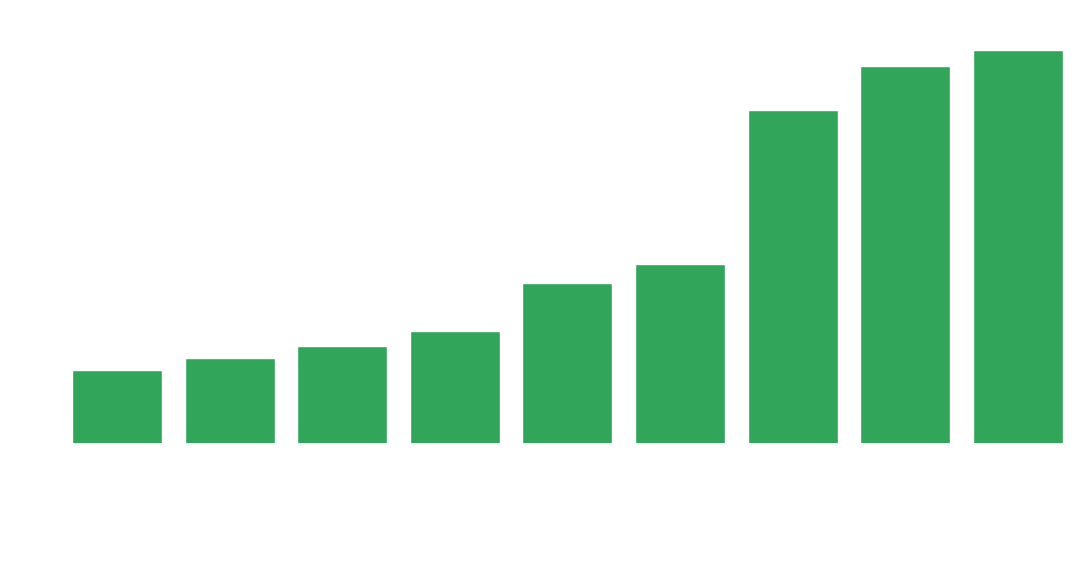

In [85]:
try:
    std_table = std_table.drop(index="popularity")
except:
    pass
std_table_sorted = std_table.sort_values('CV (%)', ascending=True)

# Create figure with dark-friendly settings
fig, ax = plt.subplots(figsize=(11, 6))

# Barplot (Spotify green)
sns.barplot(
    data=std_table_sorted,
    x=std_table_sorted.index,
    y='CV (%)',
    color="#1DB954",
    ax=ax
)

# Make background transparent (important for black slides)
fig.patch.set_alpha(0)
ax.set_facecolor("none")

# Improve readability on dark background
ax.tick_params(colors="white")
ax.xaxis.label.set_color("white")
ax.yaxis.label.set_color("white")
ax.title.set_color("white")

# Rotate x labels for readability
plt.xticks(rotation=45, ha='right', color="white")

# Labels + title
ax.set_title("Coefficient of Variation by Audio Feature (Low → High)")
ax.set_xlabel("Feature")
ax.set_ylabel("CV (%)")

# Optional: subtle grid (helps on dark slides)
ax.grid(True, axis='y', alpha=0.2, color="white")

# Tight layout so labels don’t get cut off
plt.tight_layout()

# Save with transparency for Google Slides
plt.savefig(
    "cv_plot.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()

**Interpretation:**
Here we look to the Coefficient of variation (std/mean) that tell us how big is the variation compared to the size of the average value.

- **Danceability** (mean 71, CV ~17%) and **Liveness** (mean 15, CV ~76%) emerge as the two most and least consistent features respectively.
- **BPM** has CV ~26% — moderate spread — suggesting WMR should NOT rely on tempo alone.

---
### 3.1 Genre Popularity Ranking

In [86]:
top10_genres = sp_df.genre.value_counts(ascending = False).head(10) #top_genres
top_10_genre_names = list(top10_genres.index)

filter_pop = []
filter_not = []
all_genres = list(sp_df.genre.unique())
for i in all_genres:
    if 'pop' in i:
      filter_pop.append(i)
    else:
      filter_not.append(i)

list_genres_ordered = filter_pop + filter_not


,acousticness,beats_per_minute,danceability,energy,length,liveness,loudness_db,popularity,speechiness,valence
genre,,,,,,,,,,
dance pop,27.000000,111.875000,70.250000,59.875000,202.625000,15.500000,-6.125000,85.750000,15.250000,45.875000
electropop,29.000000,135.000000,68.500000,44.000000,194.500000,11.000000,-11.000000,92.000000,34.000000,62.000000
pop,21.428571,114.142857,68.428571,63.285714,195.428571,12.142857,-6.285714,85.857143,9.285714,58.000000
pop house,4.000000,124.000000,68.000000,74.000000,153.000000,7.000000,-7.000000,91.000000,3.000000,63.000000
panamanian pop,10.500000,176.000000,74.000000,74.500000,257.000000,8.500000,-3.500000,89.000000,27.000000,69.000000
canadian pop,26.500000,120.500000,72.500000,68.500000,191.000000,10.500000,-5.000000,74.500000,4.500000,81.000000
australian pop,69.000000,98.000000,82.000000,59.000000,210.000000,18.000000,-6.000000,83.000000,10.000000,54.000000
canadian hip hop,21.666667,109.000000,80.000000,45.000000,193.000000,15.000000,-6.333333,89.666667,5.333333,33.333333
reggaeton flow,11.000000,98.500000,80.000000,80.000000,305.500000,8.500000,-4.000000,87.500000,8.000000,59.500000


<Axes: ylabel='genre'>

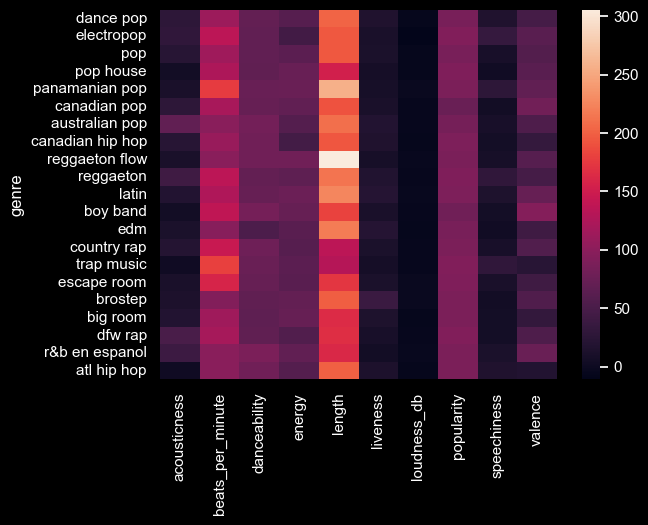

In [87]:
results = sp_df.pivot_table(index='genre',values= numeric_data, aggfunc='mean')
results = results.reindex(index=list_genres_ordered)
display(results)
sns.heatmap(results,annot=False)

# zscore_df=(results-results.min())/(results.max()-results.min())
# sns.heatmap(zscore_df, annot=False)
# results = sp_df.pivot_table(index='genre',values= numeric_data, aggfunc='mean')
# results = sp_df.pivot_table(index='genre',values= numeric_data, aggfunc='std')
# results = results.reindex(index=list_genres_ordered)
# sns.heatmap(results,annot=False)

/var/folders/y7/p6n8z7nn4fs88vn9n57nxbh40000gn/T/ipykernel_10052/2383998327.py:7: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  values_top_songs = binned_means_pivot_all.stack().head(10)


,acousticness,beats_per_minute,danceability,energy,length,liveness,loudness_db,popularity,speechiness,valence
rank,,,,,,,,,,
0.0,29.6,149.2,68.6,63.0,210.6,12.0,-6.0,93.2,22.8,36.4
1.0,19.0,125.8,74.6,64.6,182.4,17.4,-4.8,91.2,6.2,48.4
2.0,22.2,129.4,69.6,67.4,204.4,8.6,-5.0,90.6,17.2,59.4
3.0,16.0,97.8,74.8,63.2,184.8,12.4,-6.4,89.2,11.4,46.2
4.0,26.0,128.8,70.6,63.8,204.4,19.4,-7.0,88.8,20.0,62.8
5.0,31.4,109.2,70.0,57.4,190.2,16.2,-6.2,88.0,5.8,52.0
6.0,10.2,130.4,73.6,72.8,200.6,25.6,-3.6,87.4,9.0,68.4
7.0,19.6,115.4,64.6,64.6,201.0,14.2,-5.4,85.6,15.8,55.8
8.0,22.4,100.8,70.4,54.8,237.6,11.8,-6.8,83.2,9.8,39.4


                        mean  max  min
rank                                  
0.0  acousticness       29.6   60    2
     beats_per_minute  149.2  180  105
     danceability       68.6   79   58
     energy             63.0   81   43
     length            210.6  302  131
     liveness           12.0   24    7
     loudness_db        -6.0   -4  -11
     popularity         93.2   95   92
     speechiness        22.8   38    7
     valence            36.4   61   18


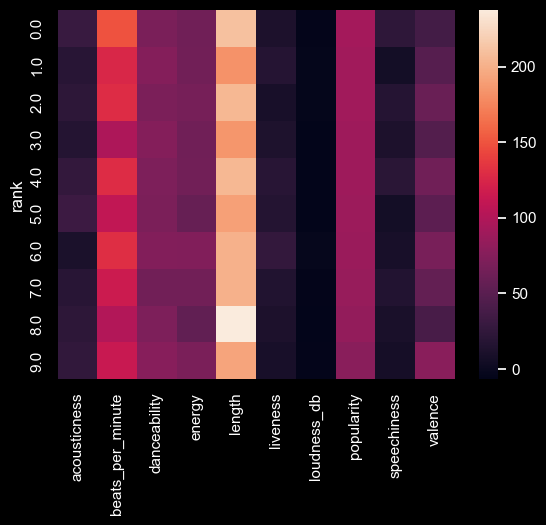

In [88]:
means_binned_by_5 =  sp_df.sort_values('popularity', ascending=False)
means_binned_by_5['rank'] = [np.floor(n/5) for n in range(50)]

binned_means_pivot = means_binned_by_5.pivot_table(index='rank',values=numeric_data,aggfunc='mean')
binned_means_pivot_all = means_binned_by_5.pivot_table(index='rank',values=numeric_data,aggfunc=['mean','max','min'])

values_top_songs = binned_means_pivot_all.stack().head(10)

sns.heatmap(binned_means_pivot,annot=False)
display(binned_means_pivot)
print(values_top_songs)

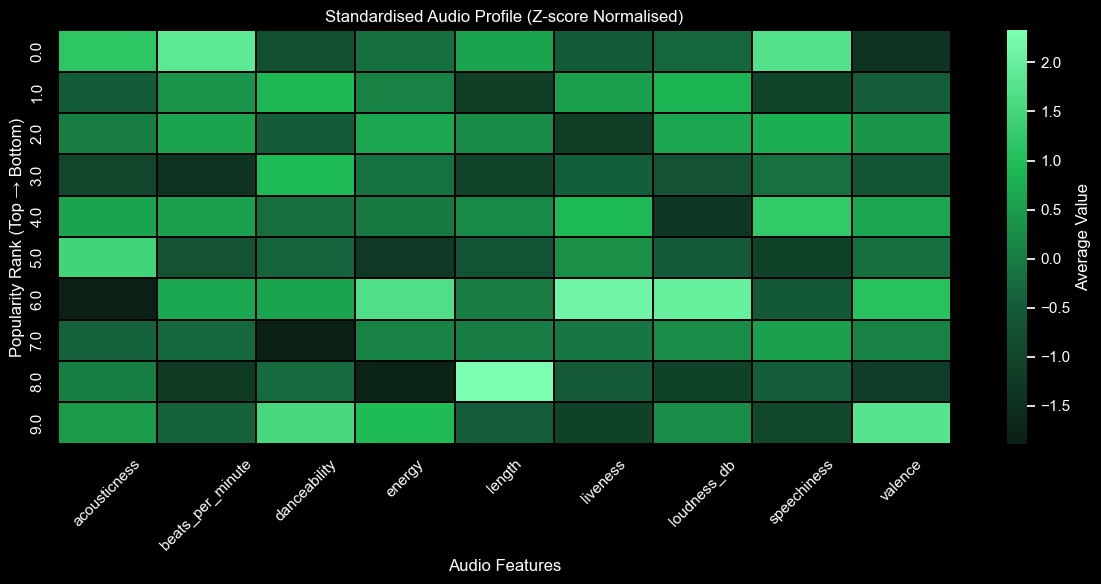

In [89]:
from matplotlib.colors import LinearSegmentedColormap

pivot_no_popularity = binned_means_pivot.copy()

pivot_no_popularity = pivot_no_popularity.drop(columns="popularity")
pivot_norm = (pivot_no_popularity - pivot_no_popularity.mean()) / pivot_no_popularity.std()


# Spotify-style dark theme
plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(12, 6))
spotify_cmap = LinearSegmentedColormap.from_list(
    "spotify_green",
    ["#0b1f14", "#145c3a", "#1DB954", "#7CFFB2"]
)

sns.heatmap(
    pivot_norm,  # your data
    cmap=spotify_cmap,  # Spotify-like green scale
    linewidths=0.3,
    linecolor="black",
    cbar_kws={"label": "Average Value"},
    ax=ax
)

# Axis labels
ax.set_xlabel("Audio Features", color="white")
ax.set_ylabel("Popularity Rank (Top → Bottom)", color="white")
ax.set_title("Standardised Audio Profile (Z-score Normalised)", color="white")

# Tick styling
ax.tick_params(axis='x', colors='white', rotation=45)
ax.tick_params(axis='y', colors='white')

# Improve colorbar styling
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.label.set_color("white")
cbar.ax.tick_params(colors="white")

plt.tight_layout()

plt.savefig(
    "heatmap.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()

beats_per_minute    141.166667
energy               60.833333
danceability         71.000000
loudness_db          -5.666667
liveness             12.000000
valence              32.000000
length              209.666667
acousticness         26.333333
speechiness          19.833333
popularity           93.000000
dtype: float64

beats_per_minute    110.333333
energy               65.000000
danceability         75.833333
loudness_db          -5.666667
liveness             10.166667
valence              66.666667
length              204.833333
acousticness         23.000000
speechiness           8.166667
popularity           78.500000
dtype: float64

<Axes: >

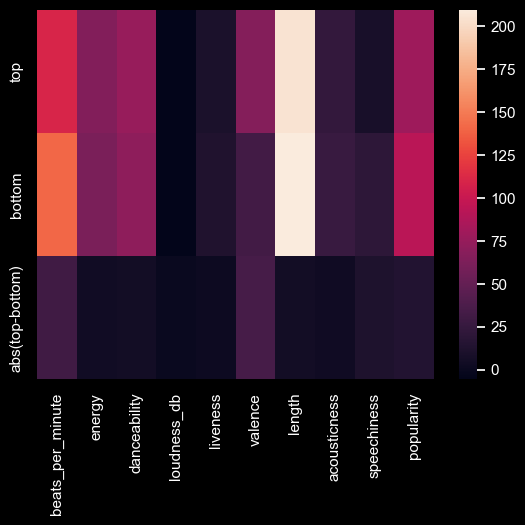

In [90]:
#Sorting the data by the ranking to be able to see a better relationship

sorted_top= sp_df.sort_values('popularity', ascending=False)
sorted_top=sorted_top.iloc[:6,:]
# display(sorted_top)
# sns.heatmap(sorted_top.loc[:,numeric_data],annot=False)


display(sorted_top.mean(numeric_only=True))

sorted_bottom= sp_df.sort_values('popularity', ascending=True)
sorted_bottom=sorted_bottom.iloc[:6,:]
# display(sorted_bottom)
# sns.heatmap(sorted_bottom.loc[:,numeric_data],annot=False)


display(sorted_bottom.mean(numeric_only=True))
bottom_means = sorted_bottom.mean(numeric_only=True)
sns.heatmap([sorted_bottom.mean(numeric_only=True), sorted_top.mean(numeric_only=True),abs(sorted_bottom.mean(numeric_only=True)-
                                                                                           sorted_top.mean(numeric_only=True))],annot=False,xticklabels=numeric_data,yticklabels=['top','bottom','abs(top-bottom)'])


,track_name,artist_name,genre,beats_per_minute,energy,danceability,loudness_db,liveness,valence,length,acousticness,speechiness,popularity
43,If I Can't Have You,Shawn Mendes,canadian pop,124,82,69,-4,13,87,191,49,6,70
23,"fuck, i'm lonely (with Anne-Marie) - from “13 ...",Lauv,dance pop,95,56,81,-6,6,68,199,48,7,78
42,Señorita,Shawn Mendes,canadian pop,117,55,76,-6,8,75,191,4,3,79
18,Sucker,Jonas Brothers,boy band,138,73,84,-5,11,95,181,4,6,80
7,No Guidance (feat. Drake),Chris Brown,dance pop,93,45,70,-7,16,14,261,12,15,82
14,Cross Me (feat. Chance the Rapper & PnB Rock),Ed Sheeran,pop,95,79,75,-6,7,61,206,21,12,82


<Axes: >

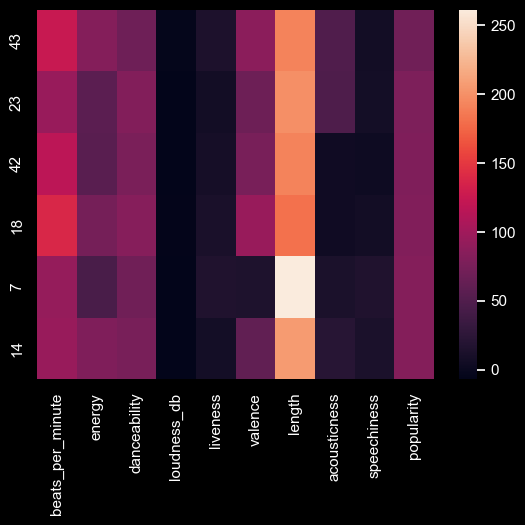

In [91]:
sorted= sp_df.sort_values('popularity', ascending=True)
sorted=sorted.iloc[:6,:]
# display(sorted.pivot_table(index='track_name', columns=numeric_data, aggfunc='mean'))
display(sorted)
sns.heatmap(sorted.loc[:,numeric_data],annot=False)

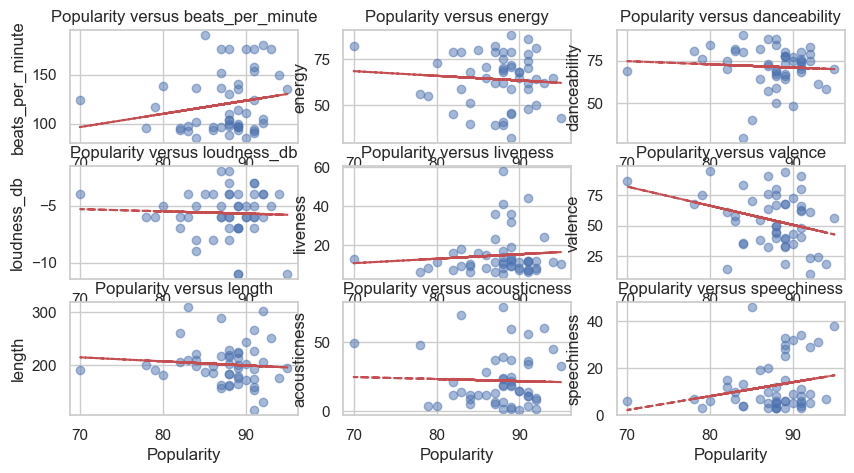

In [92]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))
for_scatter = numeric_data
# for_scatter.remove('popularity')
for i in range(len(for_scatter)-1):
    plt.subplot(3, 3, i+1)
    plt.scatter(sp_df.popularity,sp_df[for_scatter[i]], alpha=0.5)
    plt.title(f"Popularity versus {for_scatter[i]}")
    plt.xlabel('Popularity')
    plt.ylabel(f"{for_scatter[i]}")
    x= sp_df.popularity
    y= sp_df[for_scatter[i]]
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    plt.plot(x,p(x),"r--")

<Axes: >

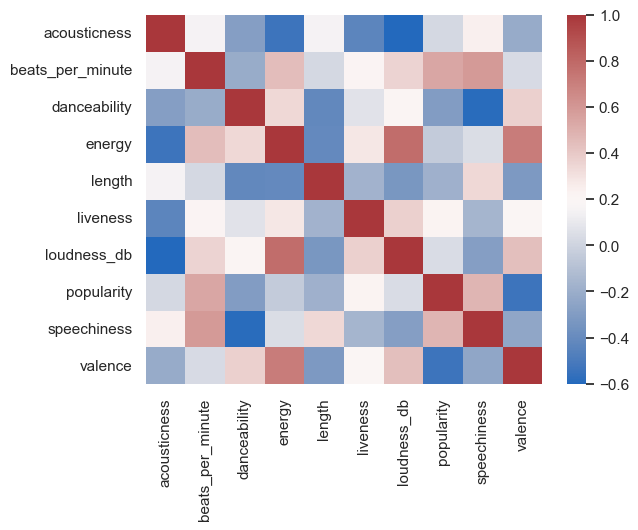

In [93]:
# mat=sp_df[numeric_data].corr(method='pearson')
# sns.heatmap(mat,annot=False,cmap="vlag")
spotify_corr = LinearSegmentedColormap.from_list(
    "spotify_corr",
    ["#2C3E50", "white", "#1DB954"]
)
cross_corr_mat=binned_means_pivot.corr(method='pearson')
sns.heatmap(cross_corr_mat,annot=False,cmap="vlag")

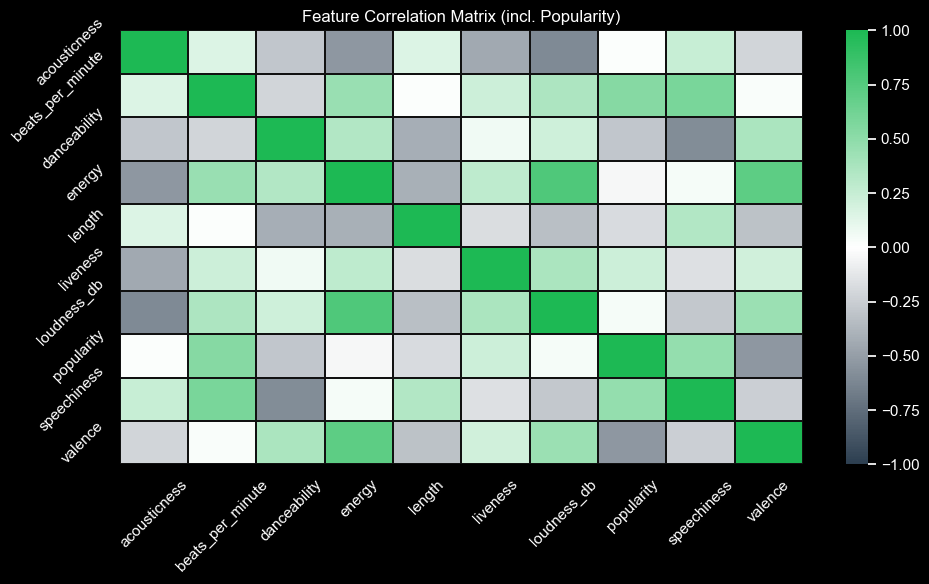

In [94]:
plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(
    cross_corr_mat,
    cmap=spotify_corr,
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.3,
    linecolor="#111",
    ax=ax
)

ax.set_title("Feature Correlation Matrix (incl. Popularity)", color="white")
ax.tick_params(colors="white", rotation=45)

plt.tight_layout()
plt.show()

---
## 4. Genre Analysis — H2: Genre differentiation

**H2 Question:** Do different genres have meaningfully different audio profiles?

In this chapter, we will look only to the metrics which standed out among the top 5 songs, as spotted in the previuos chapter.
These metrics are Beats Per Minute (BPM), valence and speechiness.

### 4.1 Metric differentiation among genres


In [95]:
#we take only the mean values of the thre metrics for all genres from our data set
f_metrics = ['beats_per_minute','valence','speechiness']
f_metrics_genre = round(sp_df.pivot_table(index='genre',values= f_metrics, aggfunc='mean'),2)
display(f_metrics_genre.head(2))

,beats_per_minute,speechiness,valence
genre,,,
atl hip hop,98.0,15.0,18.0
australian pop,98.0,10.0,54.0


Now, because these **metrics are in different scales, it is important to normalize them** so they have same scale and level of importance is not impacted by the big/low numbers of each metric scale. (if clustering on raw numbers, BPM will dominate simply because its numbers are bigger — not because it's more important. 

We choose a clustermap, to be able to show both the metric values and the groupings of genres in one view and, a dendrogram built with a Ward method which merges the closest genres into clusters, then clusters into bigger clusters allow us to do the correlation work visually for easy understanding.

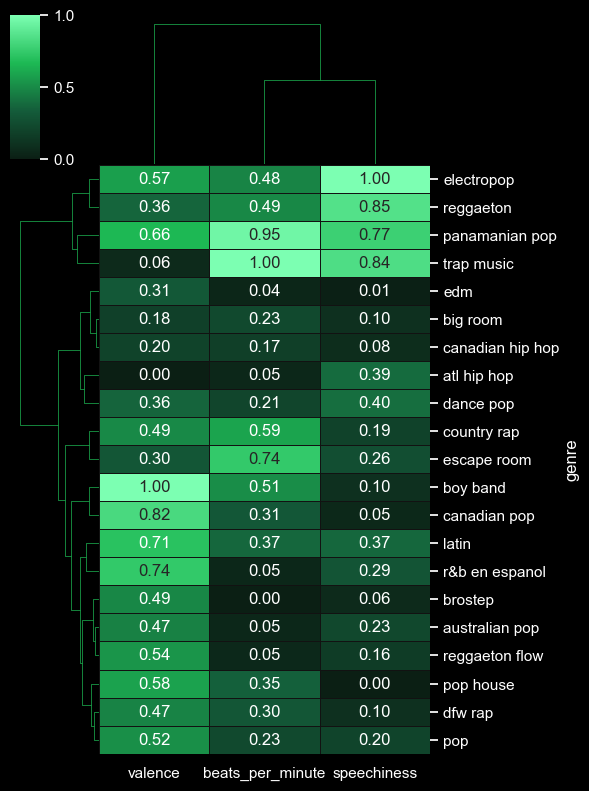

In [99]:

from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import MinMaxScaler

# Spotify-style dark theme
plt.style.use("dark_background")

#matching Spotify green colormap
spotify_cmap = LinearSegmentedColormap.from_list(
    "spotify_green", ["#0b1f14", "#145c3a", "#1DB954", "#7CFFB2"]
)

#Normalizing the data
scaler = MinMaxScaler()
normalized = f_metrics_genre.copy()
normalized[f_metrics] = scaler.fit_transform(f_metrics_genre[f_metrics])

g = sns.clustermap(
    normalized,
    cmap=spotify_cmap,  
    annot=True,
    fmt=".2f",
    figsize=(6, 8),
    linewidths=0.5,
    linecolor="#121212",  # Dark lines between cells
    method="ward",
)

#dendrogram lines need to pop on dark mode
plt.setp(g.ax_row_dendrogram.collections, color="#1DB954")
plt.setp(g.ax_col_dendrogram.collections, color="#1DB954")

#Saving the plot for slides
g.savefig('genre_clustermap',dpi=300, bbox_inches='tight')


plt.show()

From the cluster above we see that there is a differentiation per genre, thus if we profile the audios based on the three universal metrics there are different audio profiles among genres. We differentiate here by group clusters seen from the dendrogram, from this cluster are splitted into **three macro-groups**:

| Cluster Group | Included Genres | Shared Characteristics |
| :--- | :--- | :--- |
| **High Beats / High Speechiness**  | `electropop`, `reggaeton`, `panamanian pop`, `trap music` | High `speechiness` and high `beats_per_minute`. |
| **The "Mellow / Low-Tempo" Group**  | `edm` down to `dance pop` **+** `country rap` & `escape room` | Characterized by generally low values across the board, particularly very low `beats_per_minute` (with `escape room` being an outlier spike in BPM). |
| **The "High Valence" Group**  | `boy band` all the way down to `pop` | Tied together by strong, consistent `valence` (positivity/happiness score) between ~0.47 and 1.00, alongside low `speechiness`. |


### 4.2 Genre clusters vs. Top 5 songs metrics

Now we compare the genre clusters against the top 5 songs using their corresponding mean of the 3 metrics (Beats Per Minute (BPM), valence and speechiness).


In [100]:
clus1=['electropop', 'reggaeton', 'panamanian pop', 'trap music']
clus2= ['edm', 'big room', 'canadian hip hop','atl hip hop','dance pop', 'country rap','escape room']  
clus3=['boy band', 'canadian pop','latin','r&b en espanol','brostep','australian pop',
        'canadian pop','reggaeton flow','pop house','dfw rap','pop']

import numpy as np
clus_df= sp_df.copy()
conditions = [
    clus_df['genre'].isin(clus1),
    clus_df['genre'].isin(clus2),
    clus_df['genre'].isin(clus3)
]

choices = ['clus1', 'clus2', 'clus3']

clus_df['cluster'] = np.select(conditions, choices, default='unknown') 


In [101]:
clus_df.pivot_table(index='cluster',values= f_metrics, aggfunc='mean')

,beats_per_minute,speechiness,valence
cluster,,,
clus1,153.428571,30.000000,53.857143
clus2,114.473684,10.421053,41.894737
clus3,114.750000,9.000000,64.875000


In [102]:
#Now from the mean values of the metrics taken from the top rank (rank 0 previous chapter)
# loc with MultiIndex: (rank_level, metric_name)
selected = values_top_songs.loc[(0.0, f_metrics), 'mean']
print(selected)

rank                  
0.0   beats_per_minute    149.2
      valence              36.4
      speechiness          22.8
Name: mean, dtype: float64


In [103]:

clus_plot = clus_df.pivot_table(index='cluster', values=f_metrics, aggfunc='mean')

# grabbing the raw numbers
top_song_metrics = selected.values 

#Adding the row to the table to be plotted
clus_plot.loc['Top Songs (Rank 0.0)'] = top_song_metrics

#Rename the cluster rows with the descriptive name
clus_plot = clus_plot.rename(index={
    'clus1': 'High Beats / High Speechiness',
    'clus2': 'The "Mellow / Low-Tempo" Group',
    'clus3': 'The "High Valence" Group'
})

In [104]:
clus_df.pivot_table(index='cluster',values= f_metrics, aggfunc='mean')

,beats_per_minute,speechiness,valence
cluster,,,
clus1,153.428571,30.000000,53.857143
clus2,114.473684,10.421053,41.894737
clus3,114.750000,9.000000,64.875000


In [105]:
clus_plot = clus_df.pivot_table(index='cluster', values=f_metrics, aggfunc='mean')

# grabbing the raw numbers
top_song_metrics = selected.values 

#Adding the row to the table to be plotted
clus_plot.loc['Top Songs (Rank 0.0)'] = top_song_metrics

#Rename the cluster rows with the descriptive name
clus_plot = clus_plot.rename(index={
    'clus1': 'High Beats / High Speechiness',
    'clus2': 'The "Mellow / Low-Tempo" Group',
    'clus3': 'The "High Valence" Group'
})


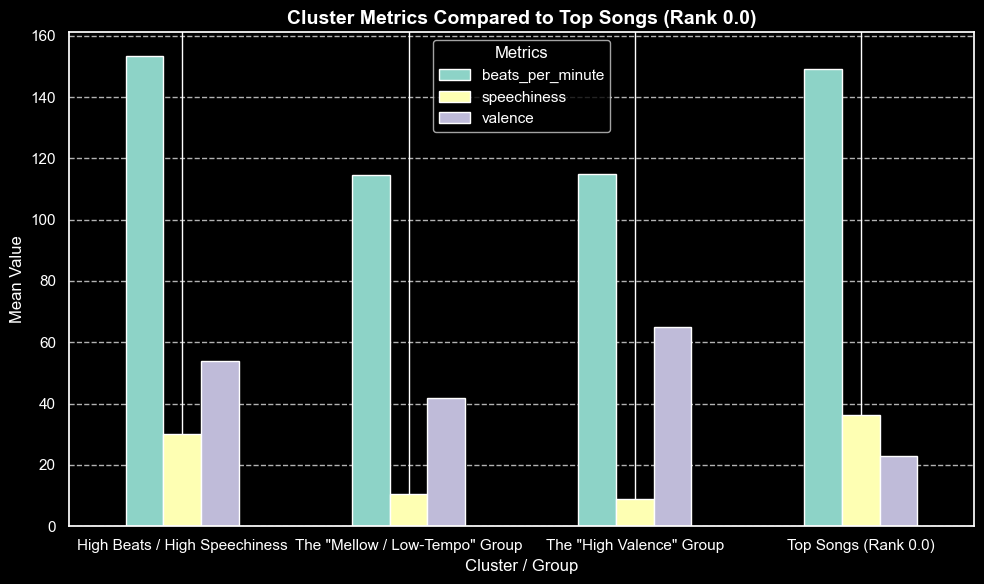

In [107]:
#Plot a grouped bar chart
clus_plot.plot(kind='bar', figsize=(10, 6))

#Improving labels for easy reading
plt.title('Cluster Metrics Compared to Top Songs (Rank 0.0)', fontsize=14, fontweight='bold')
plt.xlabel('Cluster / Group', fontsize=12)
plt.ylabel('Mean Value', fontsize=12)
plt.xticks(rotation=0) # Keeps cluster names horizontal instead of tilted
plt.grid(axis='y', linestyle='--', alpha=0.7) # Adds a subtle background grid
plt.legend(title='Metrics')

#Save plot for slides
plt.savefig('clusterVsTopsong_metrics', dpi=300, bbox_inches='tight', facecolor='auto')

#The graph
plt.tight_layout()
plt.show()

---
## 5. Conclusions & Obstacles

### H1 — Universal Formula: **Partially Confirmed** ✅

The Top 50 songs share a **consistent baseline profile** across most audio features. The universal filter below captures the typical hit:

```
Danceability  ≥ X
Energy        ≥ X
Loudness      ≥ X dB    (not too quiet / compressed)
Liveness      ≤ X         (studio / polished production)
Acousticness  ≤ X
```

**Limitation:** BPM and Valence have high variance (CV > 25%), so they should NOT be fixed in the universal filter.

---

### H2 — Genre-Specific Formula: **Confirmed** ✅

A universal formula, i.e a universal filter to spot top (trendy) songs, is not ideal and there is Genre-specific audio profiles. This is confirmed seeing how the three metrics evaluated differ among genres. 

| Cluster Group | Included Genres |
| :--- | :--- |
| **High Beats / High Speechiness**  | `electropop`, `reggaeton`, `panamanian pop`, `trap music` | 
| **The "Mellow / Low-Tempo" Group**  | `edm`, `big` ,`room` ,`canadian hip hop`, `atl hip hop`, `dance pop` ,`country rap`, `escape room` | 
| **The "High Valence" Group**  | `boy band`, `canadian pop`,`latin`,`r&b en espanol`,`brostep`,`australian pop`,`canadian pop`,`reggaeton flow`,`pop house`,`dfw rap`,`pop` | 

### 🛑 Obstacles

1. **Small sample** (50 songs) — descriptive only; no causal inference possible.
2. **No control group** — without non-charting songs, we can't isolate *what makes* a hit.
3. **Single year (2019)** — genre trends shift; these thresholds may not generalise.
